In [22]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path.cwd().parent

In [23]:
test_df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "test.csv")
model = joblib.load(PROJECT_ROOT / "models" / "apt_value_model.pkl")

In [24]:
feature_cols = [c for c in test_df.columns if c not in ["price_per_area"]]
test_df["predicted_price_per_area"] = model.predict(test_df[feature_cols])

In [25]:
test_df["gap_ratio"] = (
    (test_df["price_per_area"] - test_df["predicted_price_per_area"])
    / test_df["predicted_price_per_area"]
) * 100

In [26]:
test_df["gap_ratio"].describe()

count    13421.000000
mean        17.445908
std         19.645118
min        -51.067655
25%          4.470893
50%         13.916802
75%         27.506616
max        276.745500
Name: gap_ratio, dtype: float64

In [32]:
risk_labels = ["Critical (고평가 위험)", "High", "Moderate", "Low", "Very Low (저평가)"]
risk_bins = [0, 0.05, 0.20, 0.80, 0.95, 1.0]

In [33]:
test_df["risk_grade"] = pd.qcut(test_df["gap_ratio"], q=risk_bins, labels=risk_labels)
test_df["risk_grade"].value_counts()

risk_grade
Moderate             8052
High                 2013
Low                  2013
Critical (고평가 위험)     672
Very Low (저평가)        671
Name: count, dtype: int64

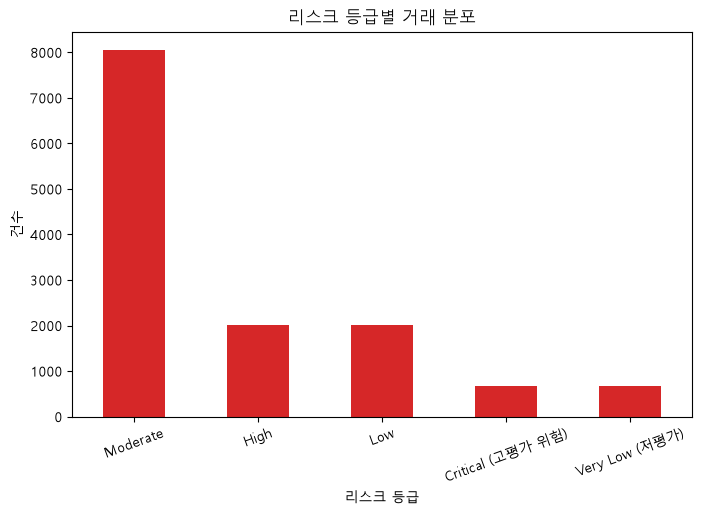

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
test_df["risk_grade"].value_counts().plot(kind="bar", ax=ax, color="tab:red")
ax.set_title("리스크 등급별 거래 분포")
ax.set_xlabel("리스크 등급")
ax.set_ylabel("건수")
plt.xticks(rotation=20)
plt.show()

In [30]:
save_path = PROJECT_ROOT / "data" / "processed"
test_df.to_csv(save_path / "risk_scored.csv", index=False)
print("저장")

저장


In [31]:
test_df.sort_values("gap_ratio", ascending=False).head(10)[
    ["aptNm_encoded", "deal_year", "deal_month", "price_per_area", "predicted_price_per_area", "gap_ratio"]
]

,aptNm_encoded,deal_year,deal_month,price_per_area,predicted_price_per_area,gap_ratio
12864,1692.416592,2025,10,6898.314782,1831.027786,276.745500
13059,1692.416592,2025,11,6596.195760,1977.644866,233.537931
10666,1692.416592,2025,1,5375.521912,1820.738478,195.238552
11240,1692.416592,2025,3,5541.949611,1904.980311,190.918997
9798,1692.416592,2024,9,5854.487548,2065.422439,183.452307
9608,1692.416592,2024,8,5738.390242,2071.945144,176.956668
9535,1692.416592,2024,8,5003.996782,1887.564216,165.103393
7136,1692.416592,2025,11,4428.571429,1694.976643,161.276251
8395,1692.416592,2024,5,4933.434048,1989.689163,147.949988
7199,1692.416592,2025,11,4428.571429,1800.398698,145.977262
